In [95]:
%pip install matplotlib
%pip install seaborn
%pip install -U scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\amnai\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\amnai\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\amnai\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [122]:
#read all the files into a single dataframe and extracted the stations name from the file name and stored it as station_source
import os
folder_path = r"C:\Users\amnai\OneDrive\Desktop\Amna\AQI Prediction\PRSA_Data_20130301-20170228"
files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
all_stations = []
for file in files:
    full_path = os.path.join(folder_path, file)
    df_temp = pd.read_csv(full_path)
    station_name = file.split('_')[2]
    df_temp['station_source'] = station_name
    all_stations.append(df_temp)

df = pd.concat(all_stations, ignore_index=True)
print(f"Combined Shape: {df.shape}")
print(f"Unique Stations found: {df['station'].unique()}")
df.head()

Combined Shape: (420768, 19)
Unique Stations found: ['Aotizhongxin' 'Changping' 'Dingling' 'Dongsi' 'Guanyuan' 'Gucheng'
 'Huairou' 'Nongzhanguan' 'Shunyi' 'Tiantan' 'Wanliu' 'Wanshouxigong']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,station_source
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,Aotizhongxin


In [123]:
#Got two station columns after the merge so checked if they have the same values and then dropped station_source
mismatch_count = (df['station'] != df['station_source']).sum()
print(f"Number of rows that dont match {mismatch_count}")

if mismatch_count == 0:
    df.drop(columns=['station_source'], inplace=True)
    print("Redundant column Removed")
df.head()

Number of rows that dont match 0
Redundant column Removed


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [124]:
#Performed linear interpolation and then filled nullvalues with it.
df.fillna(df.interpolate(method='linear'))
df.head()

C:\Users\amnai\AppData\Local\Temp\ipykernel_12500\3416517699.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.fillna(df.interpolate(method='linear'))


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [125]:
#Merged all the year, month, day, hour into a single datetime column
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.set_index('datetime', inplace=True)
df.drop(columns=['year', 'month', 'day', 'hour'], inplace=True)
df.head()

,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
2013-03-01 01:00:00,2,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2013-03-01 02:00:00,3,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
2013-03-01 03:00:00,4,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
2013-03-01 04:00:00,5,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [126]:
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['season'] = df.index.month.map(get_season)
df['is_Weekend'] = df.index.dayofweek.map(lambda x: 1 if x>=5 else 0)
print(df[['PM2.5', 'season', 'is_Weekend']].sample(5))

                     PM2.5  season  is_Weekend
datetime                                      
2015-11-26 23:00:00  125.0  Autumn           0
2014-11-25 01:00:00   70.0  Autumn           0
2014-03-20 04:00:00    6.0  Spring           0
2013-10-08 23:00:00  105.0  Autumn           0
2013-09-03 04:00:00   86.0  Autumn           0


In [127]:
def calculate_pm25_aqi(pm_val):
    if pm_val<=12.0: return ((50-0)/(12.0-0.0))*(pm_val-0.0)+0
    elif pm_val<=35.4: return ((100-51)/(35.4-12.1))*(pm_val-12.1)+51
    elif pm_val<=55.4: return ((150-101)/(55.4-35.5))*(pm_val-35.5)+101
    elif pm_val<=150.4: return ((200-151)/(150.4-55.5))*(pm_val-55.5)+151
    elif pm_val<=250.4: return ((300-201)/(250.4-150.5))*(pm_val-150.5)+201
    elif pm_val<=500.4: return ((500-301)/(500.4-250.5))*(pm_val-250.5)+301
    else: return 500

df['AQI']=df['PM2.5'].apply(calculate_pm25_aqi)
def get_aqi_bucket(aqi):
    if aqi<=50: return 'Good'
    elif aqi<=100: return 'Moderate'
    elif aqi<=150: return 'Unhealthy for sensitive'
    elif aqi<=200: return 'Unhealthy'
    elif aqi<=300: return 'Very Unhealthy'
    else: return 'Hazardous'

df['AQI_Category']= df['AQI'].apply(get_aqi_bucket)
print(df[['PM2.5', 'AQI', 'AQI_Category']].head())

                     PM2.5        AQI AQI_Category
datetime                                          
2013-03-01 00:00:00    4.0  16.666667         Good
2013-03-01 01:00:00    8.0  33.333333         Good
2013-03-01 02:00:00    7.0  29.166667         Good
2013-03-01 03:00:00    6.0  25.000000         Good
2013-03-01 04:00:00    3.0  12.500000         Good


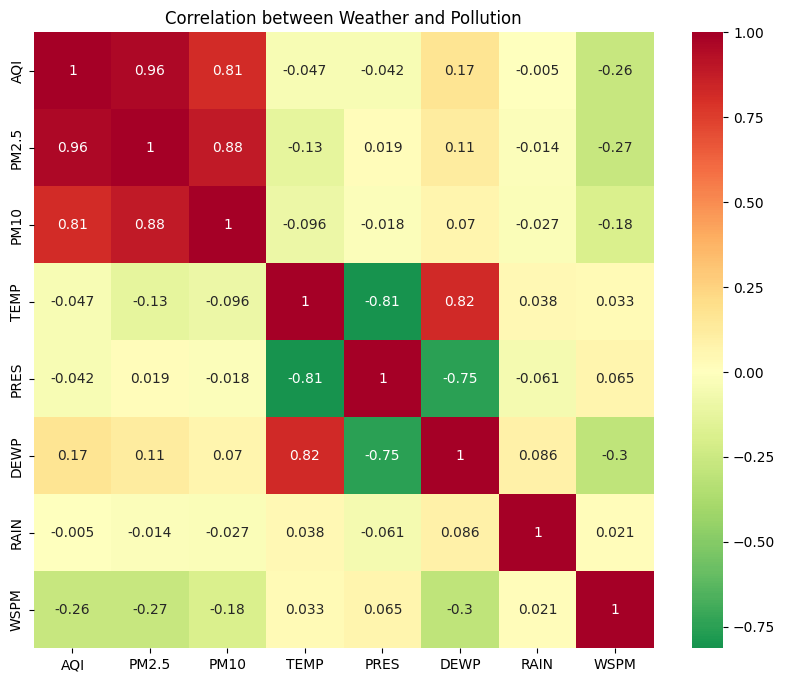

In [128]:
cols_to_check = ['AQI', 'PM2.5', 'PM10', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
corr_matrix = df[cols_to_check].corr()
plt.figure(figsize=(10,8))
sb.heatmap(corr_matrix, annot=True, cmap='RdYlGn_r', center=0)
plt.title("Correlation between Weather and Pollution")
plt.show()

C:\Users\amnai\AppData\Local\Temp\ipykernel_12500\2289282457.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df['PM2.5'].resample('M').mean()


<function matplotlib.pyplot.show(close=None, block=None)>

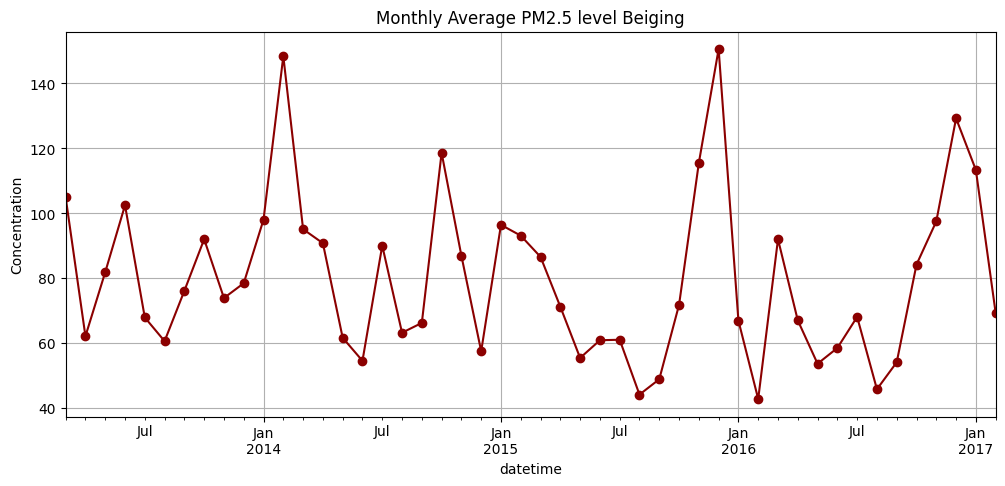

In [129]:
df_monthly = df['PM2.5'].resample('M').mean()
plt.figure(figsize=(12,5))
df_monthly.plot(kind='line', marker='o', color='darkred')
plt.title('Monthly Average PM2.5 level Beiging')
plt.ylabel('Concentration')
plt.grid(True)
plt.show

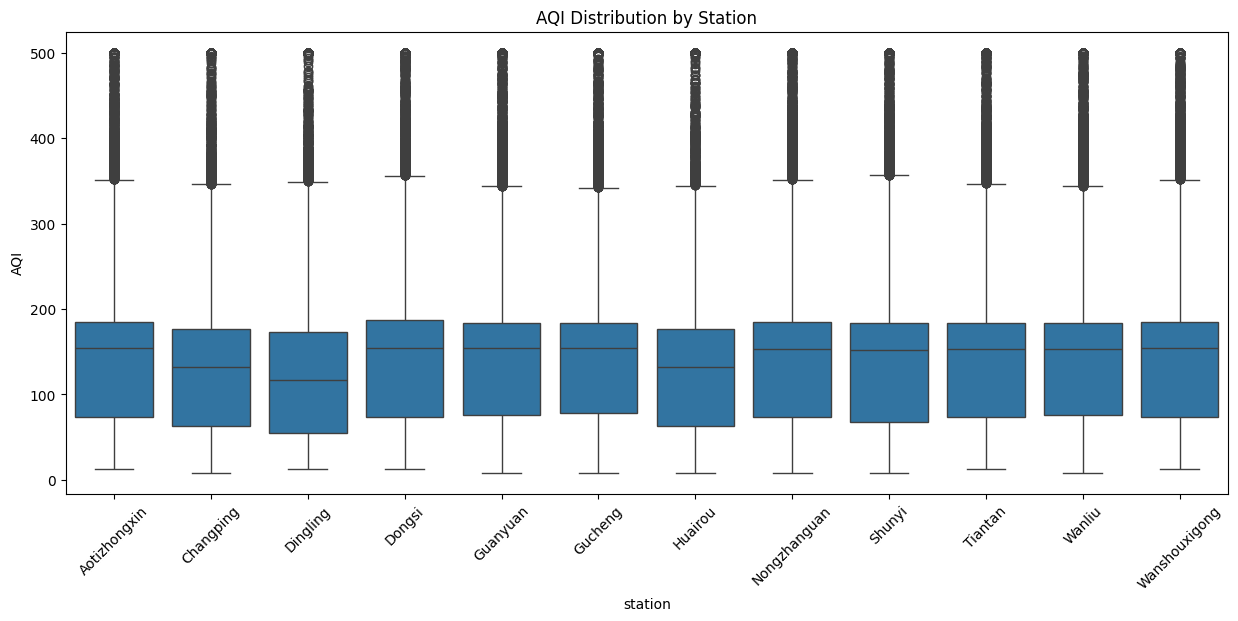

In [130]:
plt.figure(figsize=(15,6))
sb.boxplot(x='station', y='AQI', data=df)
plt.xticks(rotation=45)
plt.title('AQI Distribution by Station')
plt.show()

In [131]:
df = pd.get_dummies(df, columns=['wd'], prefix='wd')
df = pd.get_dummies(df, columns=['season'], prefix='season')
# Extract numeric features from the datetime indexdf['hour_sin'] = np.sin(2 * np.pi * df.index.hour/24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour/24)
df['month_num'] = df.index.month
df['day_of_week'] = df.index.dayofweek
# Now we have numeric versions of time! 
# We can safely drop the original 'datetime' object later.
print(df.head())

                     No  PM2.5  PM10   SO2   NO2     CO    O3  TEMP    PRES  \
datetime                                                                      
2013-03-01 00:00:00   1    4.0   4.0   4.0   7.0  300.0  77.0  -0.7  1023.0   
2013-03-01 01:00:00   2    8.0   8.0   4.0   7.0  300.0  77.0  -1.1  1023.2   
2013-03-01 02:00:00   3    7.0   7.0   5.0  10.0  300.0  73.0  -1.1  1023.5   
2013-03-01 03:00:00   4    6.0   6.0  11.0  11.0  300.0  72.0  -1.4  1024.5   
2013-03-01 04:00:00   5    3.0   3.0  12.0  12.0  300.0  72.0  -2.0  1025.2   

                     DEWP  ...   wd_W  wd_WNW wd_WSW  season_Autumn  \
datetime                   ...                                        
2013-03-01 00:00:00 -18.8  ...  False   False  False          False   
2013-03-01 01:00:00 -18.2  ...  False   False  False          False   
2013-03-01 02:00:00 -18.2  ...  False   False  False          False   
2013-03-01 03:00:00 -19.4  ...  False   False  False          False   
2013-03-01 04:00:00 

In [134]:
# Our Goal: Predict AQI
y = df['AQI']

# Our Inputs: Weather and Time features
# We drop 'AQI', 'AQI_Category', and any text columns
X = df.drop(columns=['No', 'AQI', 'AQI_Category', 'station', 'datetime', 'season', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3'], errors='ignore')

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (420768, 29)
Target (y) shape: (420768,)


In [135]:
# Split the data: 80% for training, 20% for testing
split_point = int(len(df) * 0.8)

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]
y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

print(f"Training on {len(X_train)} hours, Testing on {len(X_test)} hours.")

Training on 336614 hours, Testing on 84154 hours.


In [136]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Initialize the model
# n_estimators=100 means 100 trees. random_state ensures you get the same result if you run it again.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model
print("Training the Random Forest... please wait.")
rf_model.fit(X_train, y_train)

# 3. Make predictions
y_pred = rf_model.predict(X_test)

# 4. Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Model Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Training the Random Forest... please wait.
--- Model Results ---
Mean Absolute Error (MAE): 31.00
Root Mean Squared Error (RMSE): 59.54
R-squared Score: 0.61


C:\Users\amnai\AppData\Local\Temp\ipykernel_12500\1329372774.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


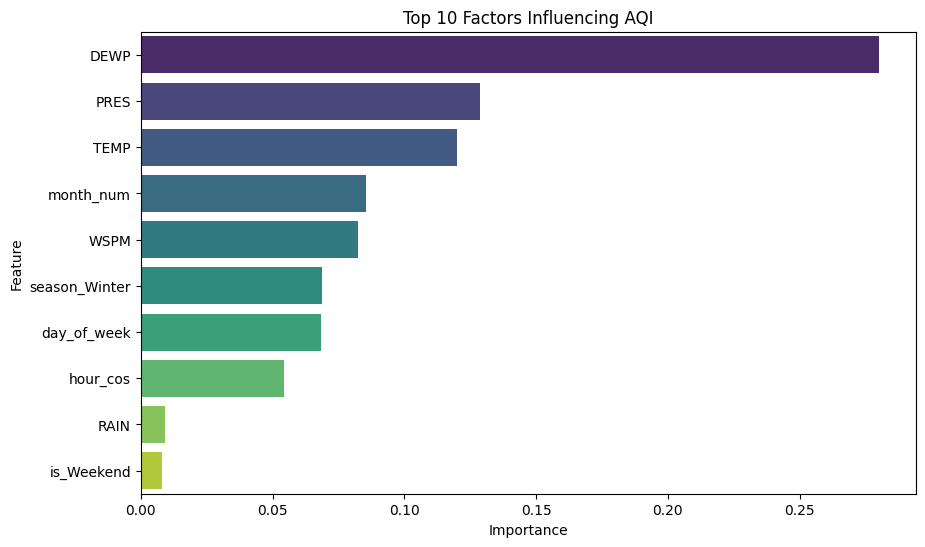

In [137]:
# Get importance levels
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort and show top 10
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sb.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title("Top 10 Factors Influencing AQI")
plt.show()

In [138]:
# Create a results dataframe
results = pd.DataFrame({
    'Actual_AQI': y_test,
    'Predicted_AQI': y_pred
}, index=X_test.index)

# Save the full cleaned data AND the results
df.to_csv('beijing_aqi_full_cleaned.csv')
results.to_csv('model_predictions_vs_actual.csv')

print("Files saved! You are now ready to leave Python and open Power BI.")

Files saved! You are now ready to leave Python and open Power BI.
